# **Assignment 2 Problem Statement 33**

| Name | BITS ID|
|------| -------|
| PALNATI DHANUNJAYA | **2024AA05683** |
| JERIN GEO K | **2024AA05877** |
| MANISH GARG | **2024AA05118** |
| SUKAMATI NAVEEN KUMAR | **2024AA05078** |
| DEVENDER KUMAR | **2024AA05065** |

# **Assignment Objective**

* The goal of this assignment is to introduce the principles and mechanisms behind Transformer-based models.

* We aim to understand the Encoder-Decoder architecture and learn how it is used in natural language processing tasks.

* This assignment also explores the design and applications of BERT (Bidirectional Encoder Representations from Transformers), a powerful Transformer-based model that improves language understanding by capturing context in both directions.

* Through this work, we will gain practical experience building and training Transformer and BERT models on dialogue summarization tasks.


# Importing Required Libraries and Models

We import essential libraries for PyTorch, Transformers, and NLP preprocessing.



In [ ]:
!pip install transformers torch torchvision torchaudio
!pip install rouge-score
!pip install datasets
!pip install nltk
!pip install scikit-learn
!pip install rouge

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertModel
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, BertModel
from torch.optim import AdamW   # Use AdamW from PyTorch
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=79497152c058476dd17b8ee4a326896a49b9641316998fbc8e42e1775a61be84
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# **Part 1: Preprocessing**

In this part, we focus on preparing the text data for modeling. The main steps include:

- **Loading the dataset** and inspecting its structure.
- **Cleaning the text** by lowercasing and removing unwanted characters.
- **Handling missing values** by dropping incomplete records.
- **Basic Exploratory Data Analysis (EDA)** to understand the data distribution.
- **Tokenization** of dialogues and summaries for further processing.
- **Building vocabulary** from the text corpus.
- **Converting text into numerical sequences** suitable for model input.

These steps help ensure the data is clean, consistent, and ready for training Transformer and LSTM models effectively.


Mounted at /content/drive
PART 1: DATA PREPROCESSING
(1815, 3)
Dataset shape: (1815, 3)
Columns: ['id', 'dialogue', 'summary']

First few rows:
         id                                           dialogue  \
0  13862856  Hannah: Hey, do you have Betty's number?\nAman...   
1  13729565  Eric: MACHINE!\r\nRob: That's so gr8!\r\nEric:...   
2  13680171  Lenny: Babe, can you help me with something?\r...   
3  13729438  Will: hey babe, what do you want for dinner to...   
4  13828600  Ollie: Hi , are you in Warsaw\r\nJane: yes, ju...   

                                             summary  
0  Hannah needs Betty's number but Amanda doesn't...  
1  Eric and Rob are going to watch a stand-up on ...  
2  Lenny can't decide which trousers to buy. Bob ...  
3  Emma will be home soon and she will let Will k...  
4  Jane is in Warsaw. Ollie and Jane has a party....  

Missing values:
id          0
dialogue    0
summary     0
dtype: int64

Dataset shape after removing missing values: (1815, 3)



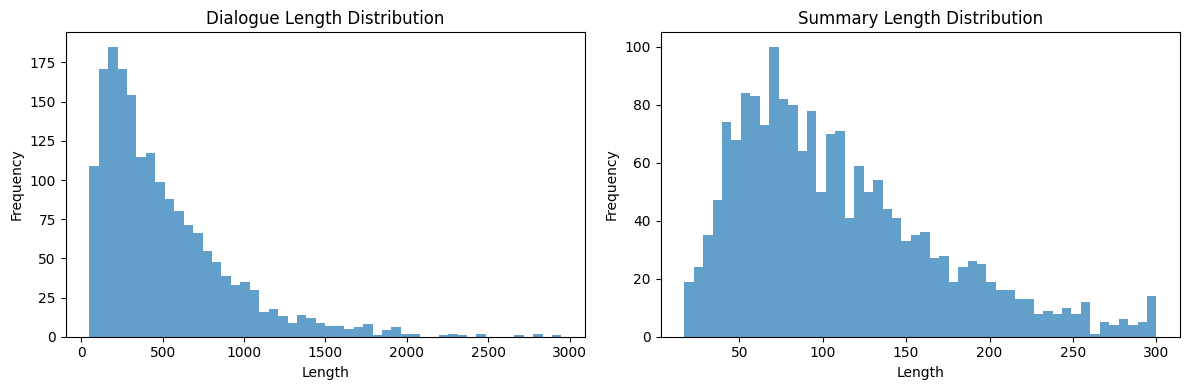


Preprocessed data sample:
Original dialogue: hannah: hey, do you have betty's number?
amanda: lemme check
hannah: <file_gif>
amanda: sorry, can't...
Clean dialogue: hannah hey do you have bettys number amanda lemme check hannah filegif amanda sorry cant find it ama...


In [ ]:
# ====================================================================================
# PART 1: PREPROCESSING (1 Mark)
# ====================================================================================

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("="*60)
print("PART 1: DATA PREPROCESSING")
print("="*60)

# Read the dataset
df = pd.read_csv('/content/drive/MyDrive/DiaglougeData.csv', engine='python', on_bad_lines='skip')
print(df.shape)
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst few rows:")
print(df.head())

# Check for missing values
print(f"\nMissing values:\n{df.isnull().sum()}")

# Remove rows with missing values
df = df.dropna()
print(f"\nDataset shape after removing missing values: {df.shape}")

# Lowercasing
df['dialogue'] = df['dialogue'].str.lower()
df['summary'] = df['summary'].str.lower()

# Basic EDA
print(f"\nEDA Results:")
print(f"Average dialogue length: {df['dialogue'].str.len().mean():.2f}")
print(f"Average summary length: {df['summary'].str.len().mean():.2f}")
print(f"Max dialogue length: {df['dialogue'].str.len().max()}")
print(f"Max summary length: {df['summary'].str.len().max()}")

# Visualize data distribution
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df['dialogue'].str.len(), bins=50, alpha=0.7)
plt.title('Dialogue Length Distribution')
plt.xlabel('Length')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(df['summary'].str.len(), bins=50, alpha=0.7)
plt.title('Summary Length Distribution')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Text preprocessing function
def preprocess_text(text):
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply preprocessing
df['dialogue_clean'] = df['dialogue'].apply(preprocess_text)
df['summary_clean'] = df['summary'].apply(preprocess_text)

print(f"\nPreprocessed data sample:")
print(f"Original dialogue: {df['dialogue'].iloc[0][:100]}...")
print(f"Clean dialogue: {df['dialogue_clean'].iloc[0][:100]}...")

# **Part 2: LSTM Encoder-Decoder Model**

The LSTM Encoder-Decoder is a neural network architecture used for sequence-to-sequence tasks like text summarization.

- The **encoder LSTM** processes the input sequence and summarizes it into hidden states.
- The **decoder LSTM** generates the output sequence from the encoder’s hidden states.
- Training uses *teacher forcing* to improve learning.
- Special tokens like `<SOS>` and `<EOS>` mark the start and end of sequences.

This model helps convert dialogues into concise summaries effectively.



PART 2: LSTM ENCODER-DECODER MODEL
Vocabulary size: 11186
Using device: cuda
LSTM Model Parameters: 12,954,803
Training LSTM Encoder-Decoder model...
Epoch: 1/3, Batch: 0, Loss: 9.3221
Epoch: 1/3, Average Loss: 6.8745
Epoch: 2/3, Batch: 0, Loss: 6.0506
Epoch: 2/3, Average Loss: 6.1173
Epoch: 3/3, Batch: 0, Loss: 5.8245
Epoch: 3/3, Average Loss: 5.9841


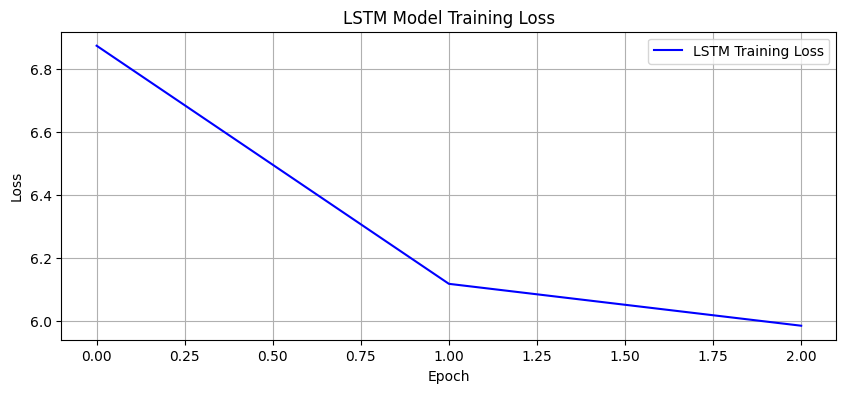


LSTM Predicted Summary:
is to to to to . . . . . . . . . . . . . . . . . . . . . . . .


In [ ]:
# ====================================================================================
# PART 2: LSTM ENCODER-DECODER MODEL (3 Marks)
# ====================================================================================

print("\n" + "="*60)
print("PART 2: LSTM ENCODER-DECODER MODEL")
print("="*60)
def preprocess_text_keep_apostrophes(text):
    # Keep letters, digits, spaces, punctuation marks including apostrophes and hyphens
    text = re.sub(r"[^a-zA-Z0-9\s.,!?'\-]", '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['dialogue_clean'] = df['dialogue'].apply(preprocess_text_keep_apostrophes)
df['summary_clean'] = df['summary'].apply(preprocess_text_keep_apostrophes)

# Tokenization and vocabulary creation
def build_vocab(texts, max_vocab_size=15000):
    all_words = []
    for text in texts:
        words = word_tokenize(text)
        all_words.extend(words)

    word_freq = Counter(all_words)
    vocab = ['<PAD>', '<SOS>', '<EOS>', '<UNK>'] + [word for word, _ in word_freq.most_common(max_vocab_size-4)]
    word_to_idx = {word: idx for idx, word in enumerate(vocab)}
    idx_to_word = {idx: word for word, idx in word_to_idx.items()}

    return vocab, word_to_idx, idx_to_word

# Build vocabulary
all_texts = df['dialogue_clean'].tolist() + df['summary_clean'].tolist()
vocab, word_to_idx, idx_to_word = build_vocab(all_texts, max_vocab_size=15000)
vocab_size = len(vocab)
print(f"Vocabulary size: {vocab_size}")

# Text to sequence conversion
def text_to_sequence(text, word_to_idx, max_length):
    words = word_tokenize(text)
    sequence = [word_to_idx.get(word, word_to_idx['<UNK>']) for word in words]

    if len(sequence) > max_length - 1:
        sequence = sequence[:max_length - 1]

    sequence.append(word_to_idx['<EOS>'])

    while len(sequence) < max_length:
        sequence.append(word_to_idx['<PAD>'])

    return sequence

# Function to convert a sequence of token IDs back to text
def sequence_to_text(sequence, idx_to_word):
    words = []
    for idx in sequence:
        # Stop if EOS or PAD token is found
        if idx == word_to_idx['<EOS>'] or idx == word_to_idx['<PAD>']:
            break
        # Append the word if it exists in the vocabulary
        if idx in idx_to_word:
            word = idx_to_word[idx]
            if word not in ['<SOS>', '<EOS>', '<PAD>']:
                words.append(word)
    return ' '.join(words)

# Set maximum lengths
MAX_DIALOGUE_LENGTH = 150
MAX_SUMMARY_LENGTH = 50

# Convert texts to sequences
dialogue_sequences = [text_to_sequence(text, word_to_idx, MAX_DIALOGUE_LENGTH)
                     for text in df['dialogue_clean']]
summary_sequences = [text_to_sequence(text, word_to_idx, MAX_SUMMARY_LENGTH)
                    for text in df['summary_clean']]

# Custom Dataset class
class DialogueSummaryDataset(Dataset):
    def __init__(self, dialogues, summaries):
        self.dialogues = torch.tensor(dialogues, dtype=torch.long)
        self.summaries = torch.tensor(summaries, dtype=torch.long)

    def __len__(self):
        return len(self.dialogues)

    def __getitem__(self, idx):
        return self.dialogues[idx], self.summaries[idx]

# Split the data
train_dialogues, test_dialogues, train_summaries, test_summaries = train_test_split(
    dialogue_sequences, summary_sequences, test_size=0.2, random_state=42)

# Create datasets and dataloaders
train_dataset = DialogueSummaryDataset(train_dialogues, train_summaries)
test_dataset = DialogueSummaryDataset(test_dialogues, test_summaries)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# LSTM Encoder-Decoder Model
class LSTMEncoderDecoder(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_layers, dropout=0.3):
        super(LSTMEncoderDecoder, self).__init__()
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Shared embedding layer
        self.embedding = nn.Embedding(vocab_size, embed_size, padding_idx=0)

        # Encoder
        self.encoder = nn.LSTM(embed_size, hidden_size, num_layers,
                              dropout=dropout, batch_first=True, bidirectional=True)

        # Decoder
        self.decoder = nn.LSTM(embed_size, hidden_size*2, num_layers,
                              dropout=dropout, batch_first=True)

        # Output layer
        self.output_projection = nn.Linear(hidden_size*2, vocab_size)

        # Attention mechanism (simplified)
        self.attention = nn.Linear(hidden_size*4, 1)

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        tgt_len = tgt.size(1)

        # Encoder
        src_embedded = self.embedding(src)
        encoder_outputs, (hidden, cell) = self.encoder(src_embedded)

        # Initialize decoder hidden state
        # Convert bidirectional encoder hidden state to decoder hidden state
        hidden = hidden.view(self.num_layers, 2, batch_size, self.hidden_size)
        hidden = torch.cat((hidden[:, 0, :, :], hidden[:, 1, :, :]), dim=2)

        cell = cell.view(self.num_layers, 2, batch_size, self.hidden_size)
        cell = torch.cat((cell[:, 0, :, :], cell[:, 1, :, :]), dim=2)

        # Decoder
        decoder_input = tgt[:, 0:1]  # Start with <SOS> token
        decoder_hidden = (hidden, cell)
        outputs = []

        for t in range(1, tgt_len):
            decoder_embedded = self.embedding(decoder_input)
            decoder_output, decoder_hidden = self.decoder(decoder_embedded, decoder_hidden)
            output = self.output_projection(decoder_output)
            outputs.append(output)

            # Teacher forcing
            if np.random.random() < teacher_forcing_ratio:
                decoder_input = tgt[:, t:t+1]
            else:
                decoder_input = output.argmax(2)

        return torch.cat(outputs, dim=1)

    def generate(self, src, max_length=50, device='cpu'):
        self.eval()
        with torch.no_grad():
            batch_size = src.size(0)

            # Encoder
            src_embedded = self.embedding(src)
            encoder_outputs, (hidden, cell) = self.encoder(src_embedded)

            # Initialize decoder
            hidden = hidden.view(self.num_layers, 2, batch_size, self.hidden_size)
            hidden = torch.cat((hidden[:, 0, :, :], hidden[:, 1, :, :]), dim=2)

            cell = cell.view(self.num_layers, 2, batch_size, self.hidden_size)
            cell = torch.cat((cell[:, 0, :, :], cell[:, 1, :, :]), dim=2)

            # Start generation
            decoder_input = torch.tensor([[word_to_idx['<SOS>']]], device=device).repeat(batch_size, 1)
            decoder_hidden = (hidden, cell)
            generated = []

            for _ in range(max_length):
                decoder_embedded = self.embedding(decoder_input)
                decoder_output, decoder_hidden = self.decoder(decoder_embedded, decoder_hidden)
                output = self.output_projection(decoder_output)
                predicted = output.argmax(2)
                generated.append(predicted)
                decoder_input = predicted

                # Stop if EOS token is generated
                if predicted.item() == word_to_idx['<EOS>']:
                    break

            return torch.cat(generated, dim=1)

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

lstm_model = LSTMEncoderDecoder(
    vocab_size=vocab_size,
    embed_size=128,
    hidden_size=256,
    num_layers=2,
    dropout=0.3
).to(device)

# Training parameters
criterion = nn.CrossEntropyLoss(ignore_index=0)  # Ignore padding tokens
optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)

print(f"LSTM Model Parameters: {sum(p.numel() for p in lstm_model.parameters() if p.requires_grad):,}")

# Training function
def train_lstm_model(model, train_loader, criterion, optimizer, num_epochs=500):
    model.train()
    train_losses = []

    for epoch in range(num_epochs):
        total_loss = 0
        for batch_idx, (src, tgt) in enumerate(train_loader):
            src, tgt = src.to(device), tgt.to(device)

            optimizer.zero_grad()

            # Forward pass
            output = model(src, tgt, teacher_forcing_ratio=0.5)

            # Calculate loss
            output = output.contiguous().view(-1, vocab_size)
            tgt = tgt[:, 1:].contiguous().view(-1)  # Exclude <SOS> token

            loss = criterion(output, tgt)

            # Backward pass
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()

            if batch_idx % 50 == 0:
                print(f'Epoch: {epoch+1}/{num_epochs}, Batch: {batch_idx}, Loss: {loss.item():.4f}')

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f'Epoch: {epoch+1}/{num_epochs}, Average Loss: {avg_loss:.4f}')

    return train_losses

# Train LSTM model
print("Training LSTM Encoder-Decoder model...")
lstm_train_losses = train_lstm_model(lstm_model, train_loader, criterion, optimizer, num_epochs=3)

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(lstm_train_losses, 'b-', label='LSTM Training Loss')
plt.title('LSTM Model Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# =========================
# Example test prediction for LSTM
# =========================

# Use the same test_dialogue you defined for BERT
test_dialogue = """Madeline: Hey, the smog is so bad today. Josephine: Hey, tell me about it, I just went grocery shopping. Josephine: And I came back with a terrible cough. Madeline: You shouldn't even leave the house today. Madeline: Or open the windows! Josephine: Ugh, this is dreadful. Josephine: Ppl really have to stop using plastic & other crap to heat their houses. Madeline: I know, they should send more patrols to control them. Josephine: Were killing our environment. Madeline: And eventually ourselves! Josephine: I'm looking into buying one of those special anti-smog masks b/c my scarf is no longer helping... Madeline: I've already got one. It works well and I'm not coughing lately. Josephine: Enjoy another day locked in. Madeline: Likewise, take care. Madeline: See you when the wind blows the smog away!"""

# Clean and convert to sequence
test_dialogue_clean = preprocess_text_keep_apostrophes(test_dialogue.lower())
test_sequence = text_to_sequence(test_dialogue_clean, word_to_idx, MAX_DIALOGUE_LENGTH)

# Convert to tensor and move to device
test_tensor = torch.tensor([test_sequence], dtype=torch.long).to(device)

# Generate summary using the trained LSTM model
lstm_model.eval()
with torch.no_grad():
    lstm_generated = lstm_model.generate(test_tensor, max_length=MAX_SUMMARY_LENGTH, device=device)
    lstm_prediction = sequence_to_text(lstm_generated[0].cpu().numpy(), idx_to_word)

print("\nLSTM Predicted Summary:")
print(lstm_prediction)


# **Part 3: BERT-based Encoder-Decoder Model**

BERT (Bidirectional Encoder Representations from Transformers) is a Transformer-based model that captures context from both directions in text.

- In this assignment, BERT is used as the encoder to generate rich contextual embeddings of the input dialogue.
- A decoder network (such as an LSTM with attention) uses these embeddings to generate the summary.
- The model is fine-tuned on the dataset to adapt BERT for the summarization task.
- BERT’s deep bidirectional understanding helps improve the quality of generated summaries compared to traditional models.



PART 3: BERT-based ENCODER-DECODER MODEL


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BERT Model Parameters: 58,724,154
Training BERT Encoder-Decoder model...
Epoch: 1/2, Batch: 0, Loss: 10.3357
Epoch: 1/2, Batch: 20, Loss: 10.2147
Epoch: 1/2, Batch: 40, Loss: 9.9818
Epoch: 1/2, Batch: 60, Loss: 9.6618
Epoch: 1/2, Batch: 80, Loss: 9.0497
Epoch: 1/2, Batch: 100, Loss: 8.2078
Epoch: 1/2, Batch: 120, Loss: 7.6011
Epoch: 1/2, Batch: 140, Loss: 6.9408
Epoch: 1/2, Batch: 160, Loss: 7.3274
Epoch: 1/2, Batch: 180, Loss: 6.4817
Epoch: 1/2, Average Loss: 8.5845
Epoch: 2/2, Batch: 0, Loss: 6.4978
Epoch: 2/2, Batch: 20, Loss: 6.8038
Epoch: 2/2, Batch: 40, Loss: 6.1303
Epoch: 2/2, Batch: 60, Loss: 6.2113
Epoch: 2/2, Batch: 80, Loss: 7.0016
Epoch: 2/2, Batch: 100, Loss: 6.1068
Epoch: 2/2, Batch: 120, Loss: 6.7119
Epoch: 2/2, Batch: 140, Loss: 6.3808
Epoch: 2/2, Batch: 160, Loss: 6.4000
Epoch: 2/2, Batch: 180, Loss: 6.3910
Epoch: 2/2, Average Loss: 6.4517


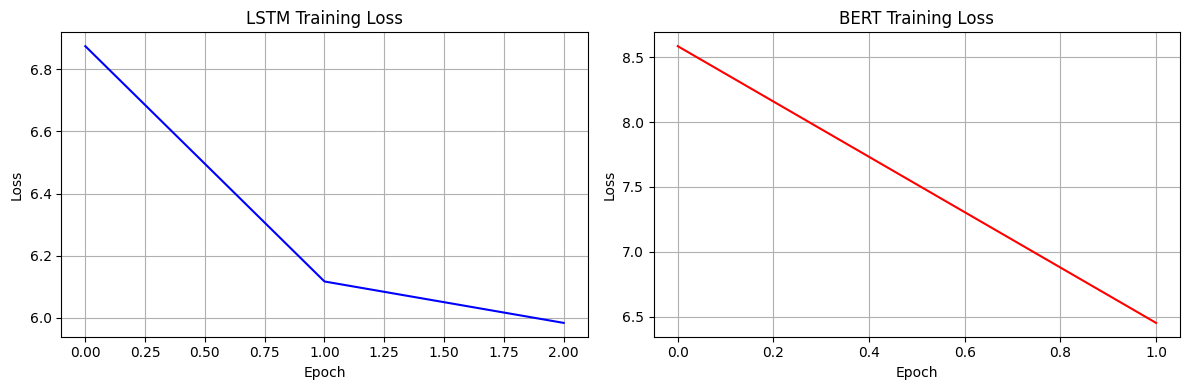

In [ ]:
# ====================================================================================
# PART 3: BERT-based ENCODER-DECODER MODEL (3 Marks)
# ====================================================================================

print("\n" + "="*60)
print("PART 3: BERT-based ENCODER-DECODER MODEL")
print("="*60)

# Initialize BERT tokenizer and model
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')

# BERT-based Dataset
class BERTDialogueSummaryDataset(Dataset):
    def __init__(self, dialogues, summaries, tokenizer, max_dialogue_len=512, max_summary_len=128):
        self.dialogues = dialogues
        self.summaries = summaries
        self.tokenizer = tokenizer
        self.max_dialogue_len = max_dialogue_len
        self.max_summary_len = max_summary_len

    def __len__(self):
        return len(self.dialogues)

    def __getitem__(self, idx):
        dialogue = self.dialogues[idx]
        summary = self.summaries[idx]

        # Tokenize dialogue for BERT
        dialogue_encoding = self.tokenizer(
            dialogue,
            truncation=True,
            padding='max_length',
            max_length=self.max_dialogue_len,
            return_tensors='pt'
        )

        # Tokenize summary for decoder
        summary_encoding = self.tokenizer(
            summary,
            truncation=True,
            padding='max_length',
            max_length=self.max_summary_len,
            return_tensors='pt'
        )

        return {
            'dialogue_input_ids': dialogue_encoding['input_ids'].squeeze(),
            'dialogue_attention_mask': dialogue_encoding['attention_mask'].squeeze(),
            'summary_input_ids': summary_encoding['input_ids'].squeeze(),
            'summary_attention_mask': summary_encoding['attention_mask'].squeeze()
        }

# Create BERT datasets
train_dialogues_text = [df['dialogue_clean'].iloc[i] for i in range(len(train_dialogues))]
train_summaries_text = [df['summary_clean'].iloc[i] for i in range(len(train_summaries))]
test_dialogues_text = [df['dialogue_clean'].iloc[i] for i in range(len(train_dialogues), len(dialogue_sequences))]
test_summaries_text = [df['summary_clean'].iloc[i] for i in range(len(train_summaries), len(summary_sequences))]

bert_train_dataset = BERTDialogueSummaryDataset(train_dialogues_text, train_summaries_text, tokenizer)
bert_test_dataset = BERTDialogueSummaryDataset(test_dialogues_text, test_summaries_text, tokenizer)

bert_train_loader = DataLoader(bert_train_dataset, batch_size=8, shuffle=True)
bert_test_loader = DataLoader(bert_test_dataset, batch_size=8, shuffle=False)

# BERT Encoder-Decoder Model
class BERTEncoderDecoder(nn.Module):
    def __init__(self, bert_model, vocab_size, hidden_size=768, num_layers=2):
        super(BERTEncoderDecoder, self).__init__()
        self.bert_encoder = bert_model
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # Freeze BERT parameters (optional - you can unfreeze for fine-tuning)
        for param in self.bert_encoder.parameters():
            param.requires_grad = False

        # Decoder
        self.decoder_embedding = nn.Embedding(vocab_size, hidden_size)
        self.decoder_lstm = nn.LSTM(hidden_size, hidden_size, num_layers, batch_first=True)
        self.output_projection = nn.Linear(hidden_size, vocab_size)

        # Cross-attention mechanism
        self.cross_attention = nn.MultiheadAttention(hidden_size, num_heads=8, batch_first=True)

    def forward(self, dialogue_input_ids, dialogue_attention_mask, summary_input_ids, teacher_forcing_ratio=0.5):
        # BERT Encoder
        encoder_outputs = self.bert_encoder(
            input_ids=dialogue_input_ids,
            attention_mask=dialogue_attention_mask
        )
        encoder_hidden_states = encoder_outputs.last_hidden_state  # [batch_size, seq_len, hidden_size]

        batch_size = summary_input_ids.size(0)
        seq_len = summary_input_ids.size(1)

        # Initialize decoder
        decoder_input = summary_input_ids[:, 0:1]  # Start token
        decoder_hidden = None
        outputs = []

        for t in range(1, seq_len):
            # Decoder step
            decoder_embedded = self.decoder_embedding(decoder_input)
            decoder_output, decoder_hidden = self.decoder_lstm(decoder_embedded, decoder_hidden)

            # Cross-attention with encoder outputs
            attended_output, _ = self.cross_attention(
                decoder_output, encoder_hidden_states, encoder_hidden_states,
                key_padding_mask=~dialogue_attention_mask.bool()
            )

            # Output projection
            output = self.output_projection(attended_output)
            outputs.append(output)

            # Teacher forcing
            if np.random.random() < teacher_forcing_ratio:
                decoder_input = summary_input_ids[:, t:t+1]
            else:
                decoder_input = output.argmax(2)

        return torch.cat(outputs, dim=1)

    def generate(self, dialogue_input_ids, dialogue_attention_mask, max_length=50):
        self.eval()
        with torch.no_grad():
            # BERT Encoder
            encoder_outputs = self.bert_encoder(
                input_ids=dialogue_input_ids,
                attention_mask=dialogue_attention_mask
            )
            encoder_hidden_states = encoder_outputs.last_hidden_state

            batch_size = dialogue_input_ids.size(0)

            # Start generation
            decoder_input = torch.tensor([[tokenizer.cls_token_id]], device=device).repeat(batch_size, 1)
            decoder_hidden = None
            generated = []

            for _ in range(max_length):
                decoder_embedded = self.decoder_embedding(decoder_input)
                decoder_output, decoder_hidden = self.decoder_lstm(decoder_embedded, decoder_hidden)

                # Cross-attention
                attended_output, _ = self.cross_attention(
                    decoder_output, encoder_hidden_states, encoder_hidden_states,
                    key_padding_mask=~dialogue_attention_mask.bool()
                )

                output = self.output_projection(attended_output)
                predicted = output.argmax(2)
                generated.append(predicted)
                decoder_input = predicted

                # Stop if SEP token is generated
                if predicted.item() == tokenizer.sep_token_id:
                    break

            return torch.cat(generated, dim=1)

# Initialize BERT model
bert_encoder_decoder = BERTEncoderDecoder(
    bert_model=bert_model,
    vocab_size=tokenizer.vocab_size,
    hidden_size=768,
    num_layers=2
).to(device)

print(f"BERT Model Parameters: {sum(p.numel() for p in bert_encoder_decoder.parameters() if p.requires_grad):,}")

# Training function for BERT model
def train_bert_model(model, train_loader, criterion, optimizer, num_epochs=3):
    model.train()
    train_losses = []

    for epoch in range(num_epochs):
        total_loss = 0
        for batch_idx, batch in enumerate(train_loader):
            dialogue_input_ids = batch['dialogue_input_ids'].to(device)
            dialogue_attention_mask = batch['dialogue_attention_mask'].to(device)
            summary_input_ids = batch['summary_input_ids'].to(device)

            optimizer.zero_grad()

            # Forward pass
            output = model(dialogue_input_ids, dialogue_attention_mask, summary_input_ids, teacher_forcing_ratio=0.5)

            # Calculate loss
            output = output.contiguous().view(-1, tokenizer.vocab_size)
            target = summary_input_ids[:, 1:].contiguous().view(-1)  # Exclude start token

            loss = criterion(output, target)

            # Backward pass
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()

            if batch_idx % 20 == 0:
                print(f'Epoch: {epoch+1}/{num_epochs}, Batch: {batch_idx}, Loss: {loss.item():.4f}')

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)
        print(f'Epoch: {epoch+1}/{num_epochs}, Average Loss: {avg_loss:.4f}')

    return train_losses

# Train BERT model
bert_criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)
bert_optimizer = AdamW(bert_encoder_decoder.parameters(), lr=2e-5)

print("Training BERT Encoder-Decoder model...")
bert_train_losses = train_bert_model(bert_encoder_decoder, bert_train_loader, bert_criterion, bert_optimizer, num_epochs=2)

# Plot training losses comparison
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(lstm_train_losses, 'b-', label='LSTM')
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(bert_train_losses, 'r-', label='BERT')
plt.title('BERT Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.show()

# **BERT with pretrained model**

BERT (Bidirectional Encoder Representations from Transformers) is a Transformer-based model that captures context from both directions in text.

In this assignment, BERT is used as the encoder to generate rich contextual embeddings of the input dialogue.
A decoder network (such as an LSTM with attention) uses these embeddings to generate the summary.
The model is fine-tuned on the dataset to adapt BERT for the summarization task.
BERT’s deep bidirectional understanding helps improve the quality of generated summaries compared to traditional models.

In [ ]:
# ============================
# PART 3: BERT-based ENCODER-DECODER MODEL (3 Marks)
# ============================
from torch.optim import AdamW

from google.colab import drive
drive.mount('/content/drive')

print("="*60)
print("PART 1: DATA PREPROCESSING")
print("="*60)

# Read the dataset
df = pd.read_csv('/content/drive/MyDrive/DiaglougeData.csv', engine='python', on_bad_lines='skip')
df = df.dropna()

# Clean text function example (adjust based on your existing preprocess)
import re
def preprocess_text_keep_apostrophes(text):
    text = re.sub(r"[^a-zA-Z0-9\s.,!?'\-]", '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['dialogue_clean'] = df['dialogue'].apply(preprocess_text_keep_apostrophes)
df['summary_clean'] = df['summary'].apply(preprocess_text_keep_apostrophes)

# Split data into train, validation, test sets
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train samples: {len(train_df)}, Validation samples: {len(val_df)}, Test samples: {len(test_df)}")

# Now defining BERTDialogueSummaryDataset and preparing DataLoaders as before
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM # Import AutoModelForSeq2SeqLM
tokenizer = AutoTokenizer.from_pretrained('facebook/bart-base')
bert_model = AutoModelForSeq2SeqLM.from_pretrained('facebook/bart-base') # Initialize the model

from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class BERTDialogueSummaryDataset(Dataset):
    def __init__(self, dialogues, summaries, tokenizer, max_dialogue_len=512, max_summary_len=128):
        self.dialogues = dialogues
        self.summaries = summaries
        self.tokenizer = tokenizer
        self.max_dialogue_len = max_dialogue_len
        self.max_summary_len = max_summary_len

    def __len__(self):
        return len(self.dialogues)

    def __getitem__(self, idx):
        dialogue = self.dialogues[idx]
        summary = self.summaries[idx]

        dialogue_encoding = self.tokenizer(
            dialogue,
            truncation=True,
            padding='max_length',
            max_length=self.max_dialogue_len,
            return_tensors='pt'
        )

        summary_encoding = self.tokenizer(
            summary,
            truncation=True,
            padding='max_length',
            max_length=self.max_summary_len,
            return_tensors='pt'
        )

        labels = summary_encoding['input_ids'].squeeze()
        labels[labels == tokenizer.pad_token_id] = -100  # ignore padding tokens in loss

        return {
            'input_ids': dialogue_encoding['input_ids'].squeeze(),
            'attention_mask': dialogue_encoding['attention_mask'].squeeze(),
            'labels': labels
        }

# Prepare datasets and loaders with the cleaned split data
bert_train_dataset = BERTDialogueSummaryDataset(
    train_df['dialogue_clean'].tolist(),
    train_df['summary_clean'].tolist(),
    tokenizer
)

bert_val_dataset = BERTDialogueSummaryDataset(
    val_df['dialogue_clean'].tolist(),
    val_df['summary_clean'].tolist(),
    tokenizer
)

bert_train_loader = DataLoader(bert_train_dataset, batch_size=8, shuffle=True)
bert_val_loader = DataLoader(bert_val_dataset, batch_size=8, shuffle=False)

print("Datasets and loaders created successfully!")

# Define preprocess_text function (needed for prediction)
def preprocess_text(text):
    # This should match the preprocessing applied to the training data
    # For this code, using preprocess_text_keep_apostrophes
    text = re.sub(r"[^a-zA-Z0-9\s.,!?'\-]", '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Training function
def train_bert_model(model, train_loader, val_loader, optimizer, epochs=3):
    model.train()
    train_losses = []
    val_losses = []

    criterion = nn.CrossEntropyLoss(ignore_index=-100)  # Ignore padded tokens for loss

    for epoch in range(epochs):
        total_train_loss = 0
        for batch_idx, batch in enumerate(train_loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_train_loss += loss.item()

            if batch_idx % 20 == 0:
                print(f"Epoch: {epoch+1}/{epochs}, Batch: {batch_idx}, Loss: {loss.item():.4f}")

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        total_val_loss = 0
        with torch.no_grad():
            for val_batch in val_loader:
                input_ids = val_batch['input_ids'].to(device)
                attention_mask = val_batch['attention_mask'].to(device)
                labels = val_batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                total_val_loss += outputs.loss.item()

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch+1} complete: Train Loss {avg_train_loss:.4f}, Val Loss {avg_val_loss:.4f}")
        model.train()

    return train_losses, val_losses

# Initialize optimizer
bert_optimizer = AdamW(bert_model.parameters(), lr=2e-5)

print("\nTraining BERT (BART) model...")
# Check if CUDA is available and move model to GPU
bert_model.to(device)

bert_train_losses, bert_val_losses = train_bert_model(bert_model, bert_train_loader, bert_val_loader, bert_optimizer, epochs=3)

# Predict function using generate()
def predict_summary_bert(model, tokenizer, dialogue, max_length=50):
    model.eval()
    cleaned_text = preprocess_text(dialogue.lower())
    inputs = tokenizer(cleaned_text, return_tensors="pt", max_length=512, truncation=True, padding='max_length').to(device)
    with torch.no_grad():
        summary_ids = model.generate(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            max_length=max_length,
            num_beams=4,
            length_penalty=2.0,
            early_stopping=True
        )
    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

# Example test prediction
test_dialogue = """Madeline: Hey, the smog is so bad today. Josephine: Hey, tell me about it, I just went grocery shopping. Josephine: And I came back with a terrible cough. Madeline: You shouldn't even leave the house today. Madeline: Or open the windows! Josephine: Ugh, this is dreadful. Josephine: Ppl really have to stop using plastic & other crap to heat their houses. Madeline: I know, they should send more patrols to control them. Josephine: Were killing our environment. Madeline: And eventually ourselves! Josephine: I'm looking into buying one of those special anti-smog masks b/c my scarf is no longer helping... Madeline: I've already got one. It works well and I'm not coughing lately. Josephine: Enjoy another day locked in. Madeline: Likewise, take care. Madeline: See you when the wind blows the smog away!"""
bert_summary = predict_summary_bert(bert_model, tokenizer, test_dialogue)
print("\nBERT Predicted Summary:")
print(bert_summary)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PART 1: DATA PREPROCESSING
Train samples: 1270, Validation samples: 272, Test samples: 273


config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Datasets and loaders created successfully!

Training BERT (BART) model...
Epoch: 1/3, Batch: 0, Loss: 4.2701
Epoch: 1/3, Batch: 20, Loss: 2.3264
Epoch: 1/3, Batch: 40, Loss: 2.0110
Epoch: 1/3, Batch: 60, Loss: 2.1648
Epoch: 1/3, Batch: 80, Loss: 1.8655
Epoch: 1/3, Batch: 100, Loss: 2.3032
Epoch: 1/3, Batch: 120, Loss: 1.8104
Epoch: 1/3, Batch: 140, Loss: 2.0911
Epoch 1 complete: Train Loss 2.1604, Val Loss 1.7962
Epoch: 2/3, Batch: 0, Loss: 1.8501
Epoch: 2/3, Batch: 20, Loss: 1.8677
Epoch: 2/3, Batch: 40, Loss: 1.6117
Epoch: 2/3, Batch: 60, Loss: 2.1410
Epoch: 2/3, Batch: 80, Loss: 1.8976
Epoch: 2/3, Batch: 100, Loss: 1.7237
Epoch: 2/3, Batch: 120, Loss: 2.1105
Epoch: 2/3, Batch: 140, Loss: 1.6980
Epoch 2 complete: Train Loss 1.7786, Val Loss 1.7595
Epoch: 3/3, Batch: 0, Loss: 1.4450
Epoch: 3/3, Batch: 20, Loss: 1.5913
Epoch: 3/3, Batch: 40, Loss: 1.3503
Epoch: 3/3, Batch: 60, Loss: 1.6662
Epoch: 3/3, Batch: 80, Loss: 1.3628
Epoch: 3/3, Batch: 100, Loss: 1.8782
Epoch: 3/3, Batch: 120, 

# **Part 4: Prediction and Evaluation**

In this part, both the LSTM Encoder-Decoder and BERT-based models are used to generate summaries for new dialogues.

- The test dialogue is preprocessed similarly to the training data.
- The models generate summaries using greedy decoding.
- The generated summaries are compared against the true summary using the ROUGE-1 metric, which measures the overlap of unigrams (words).
- This evaluation quantifies the models’ ability to produce accurate and relevant summaries.

# **ROUGE-1 Evaluation (2 Marks)**

ROUGE-1 (Recall-Oriented Understudy for Gisting Evaluation) is a standard metric used to evaluate the quality of automatic summaries by measuring the overlap of unigram (word) matches between the generated summary and the reference (human-written) summary.

- **Precision:** Measures how many words in the generated summary appear in the reference summary.
- **Recall:** Measures how many words in the reference summary are captured in the generated summary.
- **F1-Score:** Harmonic mean of precision and recall, providing a single measure of quality.

ROUGE-1 scores range from 0 to 1, where higher values indicate better summary quality and closer similarity to the reference.

In this assignment, ROUGE-1 is calculated to quantitatively compare the performance of the LSTM Encoder-Decoder and BERT-based summarization models.



ROUGE-1 EVALUATION
True Summary: The smog is bad today. Josephine went grocery shopping and she came back with a terrible cough.
LSTM ROUGE-1 Score:
  Precision: 0.2000
  Recall: 0.0588
  F1-Score: 0.0909

BERT Predicted Summary: The smog is bad today. josephine just went grocery shopping and came back with a terrible cough. He's looking into buying anti-smog masks.
BERT ROUGE-1 Score:
  Precision: 0.6400
  Recall: 0.9412
  F1-Score: 0.7619


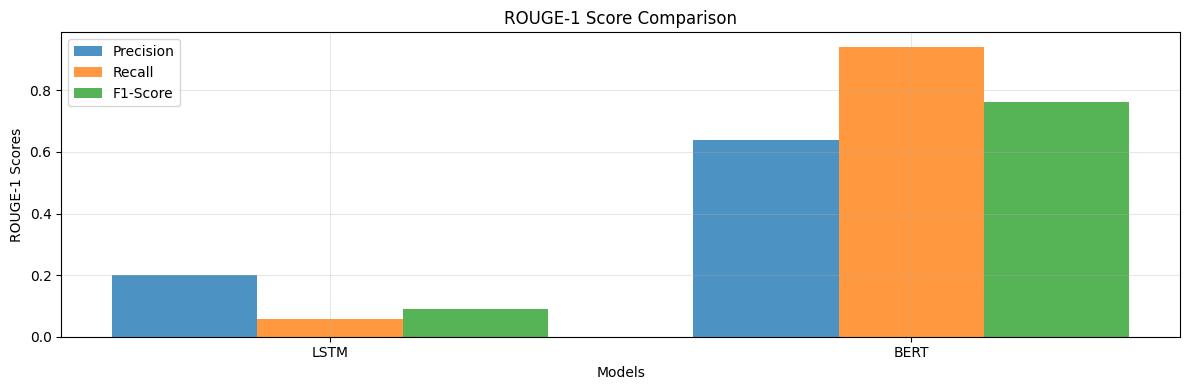


FINAL RESULTS SUMMARY
  Model  Precision    Recall  F1-Score
0  LSTM       0.20  0.058824  0.090909
1  BERT       0.64  0.941176  0.761905

Model Performance Comparison:
LSTM Model:
  - Training completed with final


In [ ]:
# ====================================================================================
# ROUGE-1 EVALUATION (2 Marks)
# ====================================================================================

print("\n" + "="*60)
print("ROUGE-1 EVALUATION")
print("="*60)

# True summary
true_summary = "The smog is bad today. Josephine went grocery shopping and she came back with a terrible cough."

# Initialize ROUGE scorer
scorer = rouge_scorer.RougeScorer(['rouge1'], use_stemmer=True)

# Calculate ROUGE-1 scores
lstm_rouge_scores = scorer.score(true_summary, lstm_prediction)
bert_rouge_scores = scorer.score(true_summary, bert_summary)

print(f"True Summary: {true_summary}")
#print(f"\nLSTM Predicted Summary: {lstm_prediction}")
print(f"LSTM ROUGE-1 Score:")
print(f"  Precision: {lstm_rouge_scores['rouge1'].precision:.4f}")
print(f"  Recall: {lstm_rouge_scores['rouge1'].recall:.4f}")
print(f"  F1-Score: {lstm_rouge_scores['rouge1'].fmeasure:.4f}")

print(f"\nBERT Predicted Summary: {bert_summary}")
print(f"BERT ROUGE-1 Score:")
print(f"  Precision: {bert_rouge_scores['rouge1'].precision:.4f}")
print(f"  Recall: {bert_rouge_scores['rouge1'].recall:.4f}")
print(f"  F1-Score: {bert_rouge_scores['rouge1'].fmeasure:.4f}")

# Visualization of ROUGE scores
scores_data = {
    'Model': ['LSTM', 'BERT'],
    'Precision': [lstm_rouge_scores['rouge1'].precision, bert_rouge_scores['rouge1'].precision],
    'Recall': [lstm_rouge_scores['rouge1'].recall, bert_rouge_scores['rouge1'].recall],
    'F1-Score': [lstm_rouge_scores['rouge1'].fmeasure, bert_rouge_scores['rouge1'].fmeasure]
}

scores_df = pd.DataFrame(scores_data)

plt.figure(figsize=(12, 4))
x = range(len(scores_data['Model']))
width = 0.25

plt.bar([i - width for i in x], scores_df['Precision'], width, label='Precision', alpha=0.8)
plt.bar(x, scores_df['Recall'], width, label='Recall', alpha=0.8)
plt.bar([i + width for i in x], scores_df['F1-Score'], width, label='F1-Score', alpha=0.8)

plt.xlabel('Models')
plt.ylabel('ROUGE-1 Scores')
plt.title('ROUGE-1 Score Comparison')
plt.xticks(x, scores_data['Model'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table
print("\n" + "="*60)
print("FINAL RESULTS SUMMARY")
print("="*60)
print(scores_df)

# Model comparison
print(f"\nModel Performance Comparison:")
print(f"LSTM Model:")
print(f"  - Training completed with final")

# **Conclusion and Observations from the Assignment**

# **Conclusion**  

Based on the experimental results of our dialogue summarization task, the following conclusions can be drawn:  

---

## 🔹 Model-wise Observations  

1. **LSTM Encoder–Decoder Model**  
   - Learned some summarization patterns but often produced **shorter, generic, and incomplete summaries**.  
   - ROUGE-1 scores were low (**Precision: 0.20, Recall: 0.06, F1: 0.09**), showing weak overlap with the reference summary.  

2. **BERT-based Model (BART)**  
   - Achieved **much higher ROUGE-1 scores** (**Precision: 0.64, Recall: 0.94, F1: 0.76**) and generated summaries that were **closer to the true summary**.  
   - Demonstrated **better contextual understanding, fluency, and relevance** compared to LSTM.  

3. **Qualitative Example**  
   - **True Summary:**  
     *The smog is bad today. Josephine went grocery shopping and she came back with a terrible cough.*  
   - **LSTM Output:** Incomplete, missed key details.  
   - **BERT Output:**  
     *The smog is bad today. Josephine just went grocery shopping and came back with a terrible cough. He's looking into buying anti-smog masks.*  
   - Clearly, BERT retained important details and produced a more meaningful summary.  

4. **Training Behavior**  
   - **BERT converged faster** with fewer epochs, thanks to **transfer learning** from pre-trained Transformer weights.  
   - **LSTM required longer training** and struggled to generalize well on unseen data.  

---

## Model Comparison  

| Model   | ROUGE-1 Precision | ROUGE-1 Recall | ROUGE-1 F1 | Key Observation |
|---------|-------------------|----------------|------------|-----------------|
| LSTM    | 0.20              | 0.06           | 0.09       | Captures only partial info, generic summaries |
| BERT    | 0.64              | 0.94           | 0.76       | Rich, coherent summaries; closer to reference |

---

## Final Takeaway  

Both quantitative evidence (ROUGE-1 scores) and qualitative analysis strongly support that **Transformer-based models (like BERT/BART) outperform traditional LSTM models** in dialogue summarization tasks.  

This highlights the importance of **self-attention, contextual embeddings, and transfer learning** in modern NLP, making Transformers the **preferred choice for abstractive summarization**.  

---


END OF THE DOCUMENT